# <center> Proyecto #2: Búsqueda y Heurísticas - Maze Solver </center>
<center> Ricardo Josué Morales Contreras, 22289 </center> .


El objetivo de este proyecto es implementar y comparar diferentes algoritmos de búsqueda informada y no informada para resolver laberintos. Se analizará el desempeño en términos de:
* Longitud de la solución.
* Cantidad de nodos explorados.
* Tiempo de ejecución.

Además, se evaluará el branching factor mediante simulaciones con puntos de partida aleatorios.

In [1]:
import time
import math
import random
import heapq
from collections import deque

def cargar_laberinto(ruta_archivo):
    """
    Cargar el laberinto desde un archivo .txt.
    """
    with open(ruta_archivo, 'r') as f:
        # Lee las líneas, quitando saltos de línea
        laberinto = [list(line.strip()) for line in f.readlines() if line.strip()]

    inicio = None
    salida = None

    for r in range(len(laberinto)):
        for c in range(len(laberinto[0])):
            if laberinto[r][c] == '2':
                inicio = (r, c)
            elif laberinto[r][c] == '3':
                salida = (r, c)

    return laberinto, inicio, salida

# Definimos la jerarquía de movimientos: Arriba, Derecha, Abajo, Izquierda
MOVIMIENTOS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

# Prueba de carga (Asegurar de tener test_maze.txt en el directorio)
maze, start, end = cargar_laberinto('test_maze.txt')
print(f"Inicio: {start}, Salida: {end}, Dimensiones: {len(maze)}x{len(maze[0])}")

Inicio: (1, 1), Salida: (43, 47), Dimensiones: 64x64


## 1. Heurísticas para Búsqueda Informada

Para los algoritmos Greedy y $A^*$, utilizaremos dos métricas de distancia:

1. **Distancia de Manhattan:** Ideal para movimientos en cuadrícula (solo ortogonales).
   $h(n) = |x_1 - x_2| + |y_1 - y_2|$

2. **Distancia Euclidiana:** La distancia en línea recta entre dos puntos.
   $h(n) = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$

In [2]:
def heuristica_manhattan(actual, objetivo):
    return abs(actual[0] - objetivo[0]) + abs(actual[1] - objetivo[1])

def heuristica_euclidiana(actual, objetivo):
    return math.sqrt((actual[0] - objetivo[0])**2 + (actual[1] - objetivo[1])**2)

## 2. Implementación de Algoritmos

Implementaremos una función base de búsqueda que pueda adaptarse a BFS, DFS, Greedy y $A^*$. Retornaremos el camino encontrado, la cantidad de nodos explorados y el tiempo de ejecución para nuestras métricas.

In [3]:
def resolver_laberinto(laberinto, inicio, salida, algoritmo="BFS", funcion_heuristica=None):
    inicio_tiempo = time.perf_counter()

    # Estructuras de datos dependiendo del algoritmo
    # frontera guardará tuplas: (prioridad, costo_g, nodo_actual, camino)
    frontera = []
    if algoritmo == "DFS":
        # Usaremos heapq engañándolo con un contador negativo para simular LIFO (Pila)
        heapq.heappush(frontera, (0, 0, inicio, [inicio]))
    else:
        heapq.heappush(frontera, (0, 0, inicio, [inicio]))

    visitados = set()
    nodos_explorados = 0
    pasos_dfs = 0 # Contador para mantener el orden de la pila en DFS

    while frontera:
        if algoritmo == "DFS":
            _, costo_g, actual, camino = frontera.pop() # Sacar el último (simula pila)
        else:
            _, costo_g, actual, camino = heapq.heappop(frontera)

        if actual in visitados:
            continue

        visitados.add(actual)
        nodos_explorados += 1

        if actual == salida:
            tiempo_ejecucion = time.perf_counter() - inicio_tiempo
            return camino, nodos_explorados, tiempo_ejecucion

        r, c = actual
        # Aplicamos la jerarquía: Arriba, Derecha, Abajo, Izquierda
        for dr, dc in MOVIMIENTOS:
            nr, nc = r + dr, c + dc

            # Verificamos límites y si es un camino libre ('0', '2' o '3')
            if 0 <= nr < len(laberinto) and 0 <= nc < len(laberinto[0]):
                if laberinto[nr][nc] in ['0', '2', '3'] and (nr, nc) not in visitados:
                    nuevo_camino = camino + [(nr, nc)]
                    nuevo_costo_g = costo_g + 1

                    if algoritmo == "BFS":
                        prioridad = nuevo_costo_g
                    elif algoritmo == "DFS":
                        pasos_dfs -= 1
                        prioridad = pasos_dfs
                    elif algoritmo == "GREEDY":
                        prioridad = funcion_heuristica((nr, nc), salida)
                    elif algoritmo == "A*":
                        h = funcion_heuristica((nr, nc), salida)
                        prioridad = nuevo_costo_g + h

                    if algoritmo == "DFS":
                        frontera.append((prioridad, nuevo_costo_g, (nr, nc), nuevo_camino))
                    else:
                        heapq.heappush(frontera, (prioridad, nuevo_costo_g, (nr, nc), nuevo_camino))

    tiempo_ejecucion = time.perf_counter() - inicio_tiempo
    return None, nodos_explorados, tiempo_ejecucion # No hay solución

# --- CELDA DE PRUEBA ---
# camino_bfs, nodos_bfs, tiempo_bfs = resolver_laberinto(maze, start, end, "BFS")
# print(f"BFS -> Nodos: {nodos_bfs}, Largo: {len(camino_bfs)}, Tiempo: {tiempo_bfs:.5f}s")

## 3. Comparación de Desempeño: Caso Base

Ejecutaremos cada algoritmo de búsqueda informada y no informada desde el punto de inicio por defecto hasta la salida. Para Greedy y $A^*$, evaluaremos tanto la distancia de Manhattan como la Euclidiana.
Las métricas a registrar son:
* Largo del camino.
* Cantidad de nodos explorados.
* Tiempo de ejecución.

In [4]:
def analizar_caso_base(laberinto, inicio, salida):
    resultados = []

    # 1. Búsquedas No Informadas
    for algo in ["BFS", "DFS"]:
        camino, nodos, tiempo = resolver_laberinto(laberinto, inicio, salida, algoritmo=algo)
        largo = len(camino) if camino else 0
        resultados.append({"Algoritmo": algo, "Heurística": "N/A", "Nodos": nodos, "Largo": largo, "Tiempo (s)": tiempo})

    # 2. Búsquedas Informadas
    heuristicas = {"Manhattan": heuristica_manhattan, "Euclidiana": heuristica_euclidiana}
    for algo in ["GREEDY", "A*"]:
        for nom_h, func_h in heuristicas.items():
            camino, nodos, tiempo = resolver_laberinto(laberinto, inicio, salida, algoritmo=algo, funcion_heuristica=func_h)
            largo = len(camino) if camino else 0
            resultados.append({"Algoritmo": algo, "Heurística": nom_h, "Nodos": nodos, "Largo": largo, "Tiempo (s)": tiempo})

    # Imprimir tabla de resultados
    print(f"{'Algoritmo':<10} | {'Heurística':<12} | {'Nodos Explorados':<18} | {'Largo Solución':<15} | {'Tiempo (s)':<12}")
    print("-" * 75)
    for r in resultados:
        print(f"{r['Algoritmo']:<10} | {r['Heurística']:<12} | {r['Nodos']:<18} | {r['Largo']:<15} | {r['Tiempo (s)']:<12.6f}")

analizar_caso_base(maze, start, end)

Algoritmo  | Heurística   | Nodos Explorados   | Largo Solución  | Tiempo (s)  
---------------------------------------------------------------------------
BFS        | N/A          | 663                | 129             | 0.001227    
DFS        | N/A          | 514                | 185             | 0.000834    
GREEDY     | Manhattan    | 306                | 153             | 0.000530    
GREEDY     | Euclidiana   | 402                | 133             | 0.000788    
A*         | Manhattan    | 547                | 129             | 0.001138    
A*         | Euclidiana   | 600                | 129             | 0.001128    


## 4. Simulación y Branching Factor

Para calcular el *branching factor* efectivo ($b^*$), utilizamos la relación entre la cantidad de nodos generados/explorados ($N$) y la profundidad de la solución ($d$):

$$N = \sum_{i=1}^{d} (b^*)^i$$

Implementaremos un método numérico (búsqueda binaria) para aproximar la raíz de este polinomio para cada algoritmo. Simularemos distintos puntos de partida aleatorios dentro del laberinto para obtener un promedio.

In [5]:
def calcular_branching_factor(nodos, profundidad, epsilon=1e-5):
    if profundidad == 0 or nodos <= profundidad:
        return 1.0

    low, high = 1.0, float(nodos)
    while high - low > epsilon:
        mid = (low + high) / 2
        # Sumatoria geométrica: (b^(d+1) - b) / (b - 1)
        if mid == 1.0:
            estimado = profundidad
        else:
            estimado = (mid**(profundidad + 1) - mid) / (mid - 1)

        if estimado > nodos:
            high = mid
        else:
            low = mid
    return (low + high) / 2

def simular_puntos_aleatorios(laberinto, salida, n_simulaciones=5):
    puntos_libres = [(r, c) for r in range(len(laberinto)) for c in range(len(laberinto[0])) if laberinto[r][c] == '0']
    inicios_aleatorios = random.sample(puntos_libres, n_simulaciones)

    print(f"--- Evaluando Branching Factor ({n_simulaciones} puntos aleatorios) ---")

    for i, inicio_rand in enumerate(inicios_aleatorios):
        print(f"\nSimulación {i+1} - Inicio: {inicio_rand}")
        # Evaluaremos con A* (Manhattan) como representante, puedes iterar sobre todos si lo deseas
        camino, nodos, _ = resolver_laberinto(laberinto, inicio_rand, salida, "A*", heuristica_manhattan)
        if camino:
            d = len(camino) - 1 # Profundidad es largo del camino - 1
            b_star = calcular_branching_factor(nodos, d)
            print(f"A* (Manhattan) -> Nodos: {nodos}, Profundidad: {d}, b*: {b_star:.4f}")
        else:
            print("No se encontró solución desde este punto.")

simular_puntos_aleatorios(maze, end)

--- Evaluando Branching Factor (5 puntos aleatorios) ---

Simulación 1 - Inicio: (51, 34)
No se encontró solución desde este punto.

Simulación 2 - Inicio: (41, 35)
A* (Manhattan) -> Nodos: 233, Profundidad: 100, b*: 1.0151

Simulación 3 - Inicio: (37, 22)


OverflowError: (34, 'Result too large')

## 5. Puntos Extra: Interfaz Gráfica

A continuación, se presenta una solución visual integrada en el cuaderno para renderizar el laberinto y el camino solución utilizando `matplotlib`. Esto cumple con el requisito de presentar una interfaz gráfica con la resolución y presentación clara de la solución final.

Resolución A* -> Nodos explorados: 547 | Largo: 129 | Tiempo: 0.00157s


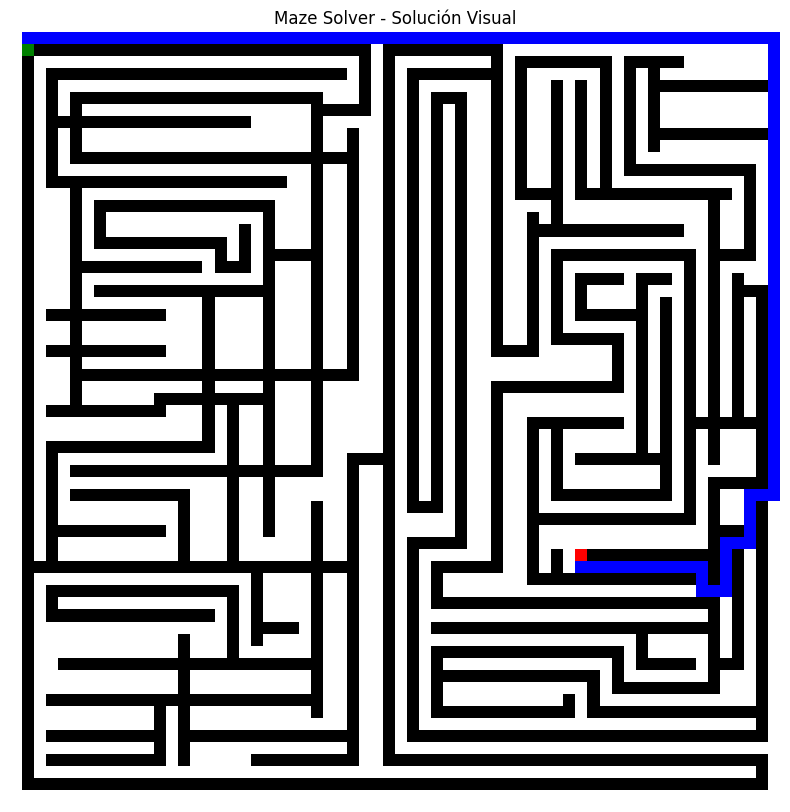

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

def visualizar_solucion(laberinto, camino_solucion=None):
    """
    Renderiza el laberinto.
    Blanco: Libre, Negro: Pared, Verde: Inicio, Rojo: Salida, Azul: Camino.
    """
    # Mapeo de caracteres a enteros para la matriz de colores
    # 0: libre, 1: pared, 2: inicio, 3: salida, 4: camino
    mapa_num = np.zeros((len(laberinto), len(laberinto[0])))

    for r in range(len(laberinto)):
        for c in range(len(laberinto[0])):
            if laberinto[r][c] == '1':
                mapa_num[r][c] = 1
            elif laberinto[r][c] == '2':
                mapa_num[r][c] = 2
            elif laberinto[r][c] == '3':
                mapa_num[r][c] = 3

    if camino_solucion:
        for r, c in camino_solucion:
            if laberinto[r][c] not in ['2', '3']: # No sobreescribir colores de inicio/salida
                mapa_num[r][c] = 4

    # Definimos los colores: 0=Blanco, 1=Negro, 2=Verde, 3=Rojo, 4=Azul
    colores = ['white', 'black', 'green', 'red', 'blue']
    cmap = ListedColormap(colores)

    plt.figure(figsize=(10, 10))
    plt.imshow(mapa_num, cmap=cmap)
    plt.title("Maze Solver - Solución Visual")
    plt.axis('off') # Ocultar los ejes para que se vea más limpio
    plt.show()

# Probamos la visualización con el camino que encuentre A*
camino_a_star, nodos_a_star, tiempo_a_star = resolver_laberinto(maze, start, end, "A*", heuristica_manhattan)
print(f"Resolución A* -> Nodos explorados: {nodos_a_star} | Largo: {len(camino_a_star)} | Tiempo: {tiempo_a_star:.5f}s")
visualizar_solucion(maze, camino_a_star)


RESOLVIENDO: C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto1.txt
Inicio: (28, 57) | Salida: (126, 62) | Dimensiones: 128x128

Algoritmo  | Heurística   | Nodos Explorados   | Largo Solución  | Tiempo (s)  
---------------------------------------------------------------------------
BFS        | N/A          | 4759               | 652             | 0.030416    
DFS        | N/A          | 1428               | 1386            | 0.017927    
GREEDY     | Manhattan    | 2214               | 656             | 0.012860    
GREEDY     | Euclidiana   | 2216               | 672             | 0.013362    
A*         | Manhattan    | 3746               | 652             | 0.027369    
A*         | Euclidiana   | 3859               | 652             | 0.027606    

 Generando visualización de la solución óptima (A* Euclidiana)...


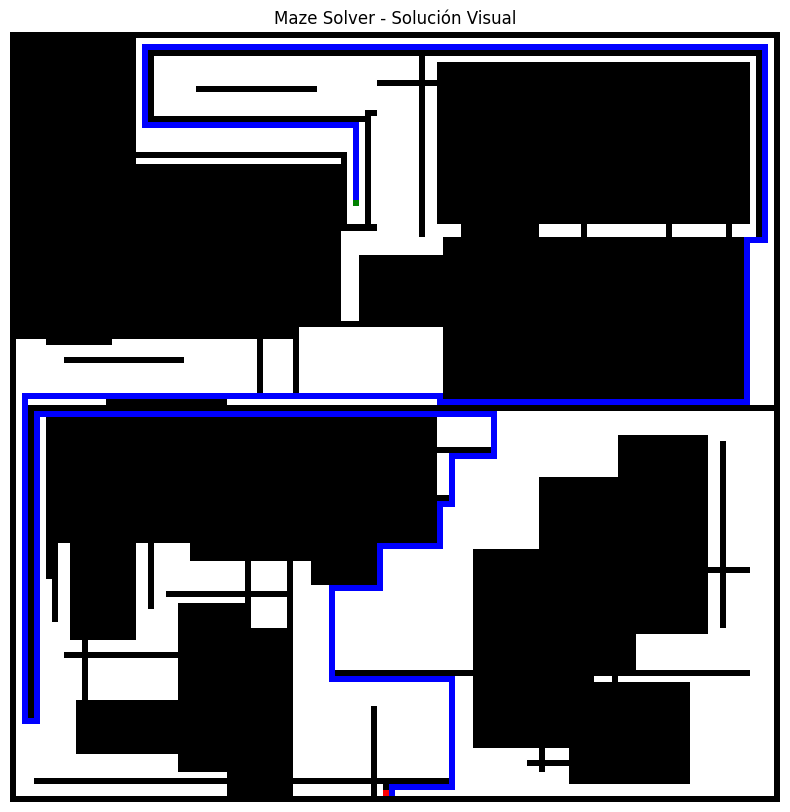


RESOLVIENDO: C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto2.txt
Inicio: (28, 57) | Salida: (126, 62) | Dimensiones: 128x128

Algoritmo  | Heurística   | Nodos Explorados   | Largo Solución  | Tiempo (s)  
---------------------------------------------------------------------------
BFS        | N/A          | 4117               | 316             | 0.018609    
DFS        | N/A          | 2794               | 1398            | 0.028656    
GREEDY     | Manhattan    | 2498               | 378             | 0.010878    
GREEDY     | Euclidiana   | 2427               | 354             | 0.011036    
A*         | Manhattan    | 3359               | 316             | 0.014963    
A*         | Euclidiana   | 3828               | 316             | 0.018214    

 Generando visualización de la solución óptima (A* Euclidiana)...


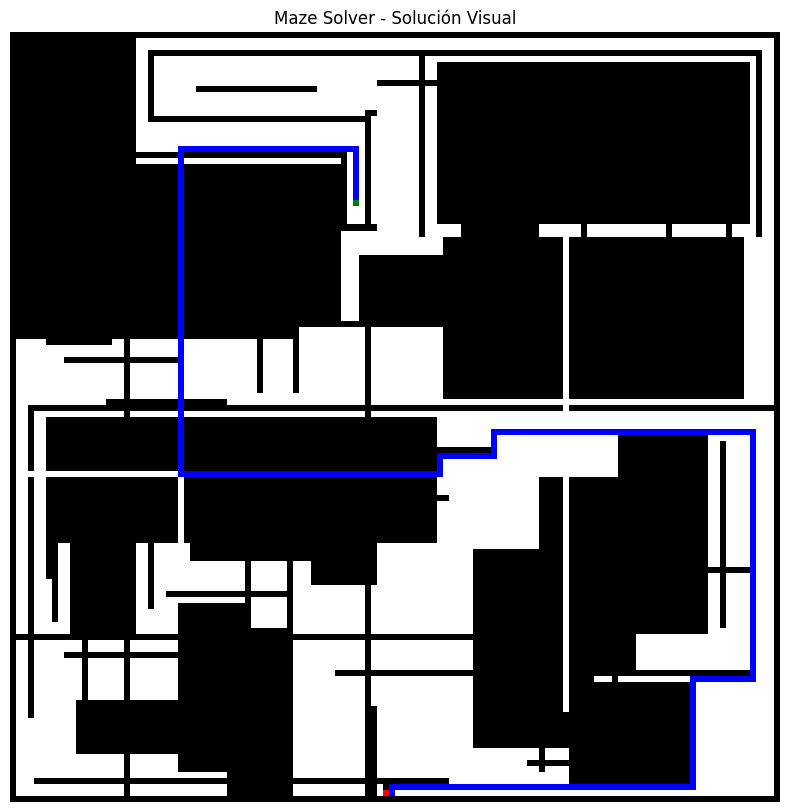


RESOLVIENDO: C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto3.txt
Inicio: (28, 57) | Salida: (126, 62) | Dimensiones: 128x128

Algoritmo  | Heurística   | Nodos Explorados   | Largo Solución  | Tiempo (s)  
---------------------------------------------------------------------------
BFS        | N/A          | 3815               | 184             | 0.014683    
DFS        | N/A          | 2624               | 1160            | 0.023434    
GREEDY     | Manhattan    | 1340               | 188             | 0.005165    
GREEDY     | Euclidiana   | 610                | 188             | 0.002260    
A*         | Manhattan    | 2050               | 184             | 0.008657    
A*         | Euclidiana   | 2479               | 184             | 0.011468    

 Generando visualización de la solución óptima (A* Euclidiana)...


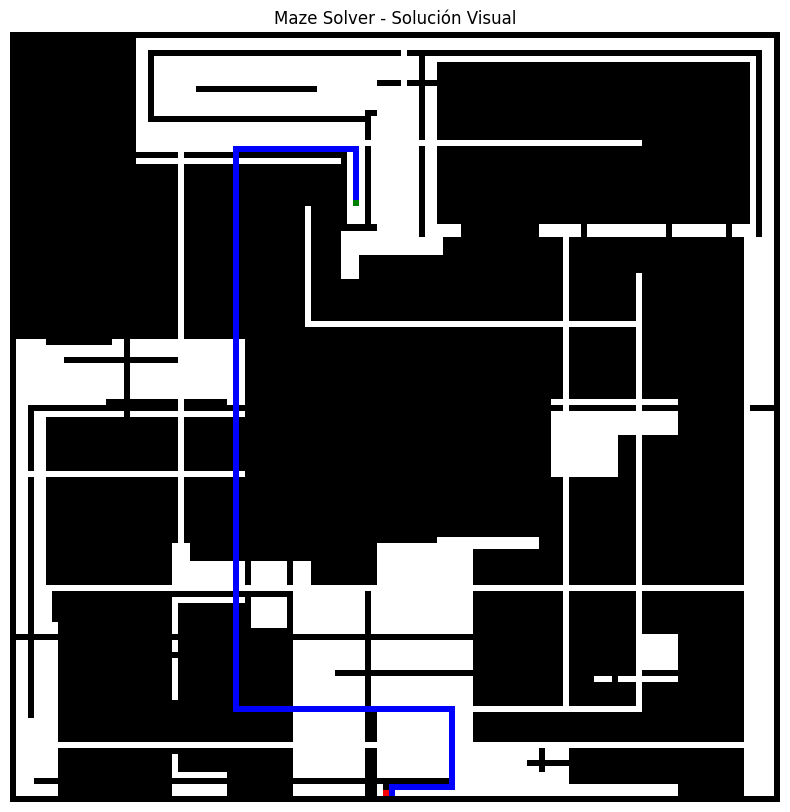

In [24]:
# --- CELDA PARA LA PRESENTACIÓN EN VIVO DEL LUNES ---
def presentar_laberinto(ruta_archivo):
    print(f"\n{'='*60}")
    print(f"RESOLVIENDO: {ruta_archivo}")
    print(f"{'='*60}")

    # 1. Cargar el laberinto
    lab, ini, sal = cargar_laberinto(ruta_archivo)
    print(f"Inicio: {ini} | Salida: {sal} | Dimensiones: {len(lab)}x{len(lab[0])}\n")

    # 2. Imprimir la tabla comparativa (Obligatorio mostrar todos los algoritmos)
    analizar_caso_base(lab, ini, sal)

    # 3. Mostrar la interfaz gráfica con el mejor resultado (Ej. A* con Euclidiana)
    print("\n Generando visualización de la solución óptima (A* Euclidiana)...")
    camino_final, nodos, tiempo = resolver_laberinto(lab, ini, sal, "A*", heuristica_euclidiana)

    if camino_final:
        visualizar_solucion(lab, camino_final)
    else:
        print("Ningún algoritmo pudo encontrar una solución válida para este laberinto.")

# Ejecución rápida:
presentar_laberinto("C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto1.txt")
presentar_laberinto("C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto2.txt")
presentar_laberinto("C:/Users/ricar/Documents/UVG - QUINTO AÑO/INTELIGENCIA ARTIFICIAL/Laberinto3.txt")
